In [1]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

## Importing Libraries

In [2]:
import torch
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms

## Device

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


## Transformation

In [4]:
transform = transforms.ToTensor()

## Data Making

In [5]:
train_data = CIFAR10(download=True, transform=transform, train=True, root="data")
test_data = CIFAR10(download=True, transform=transform, train=False, root="data")

C:\Users\abc\miniconda3\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## Data Details

In [6]:
print('----------TRAINING DATA DETAILS----------------')
print('Total training images:', len(train_data))
print("Train data classes:", train_data.classes)
print("indexes:", train_data.class_to_idx)
print()
print("----------TESTING DATA DETAILS-----------------")
print('Total testing images:', len(test_data))
print("Test data classes:", test_data.classes)
print("indexes:", test_data.class_to_idx)

----------TRAINING DATA DETAILS----------------
Total training images: 50000
Train data classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
indexes: {'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}

----------TESTING DATA DETAILS-----------------
Total testing images: 10000
Test data classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
indexes: {'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


## Image Detail

In [7]:
image, label = train_data[45]
print("Image size:", image.size())
print("Label:", label)

Image size: torch.Size([3, 32, 32])
Label: 1


## Visualizing the Image

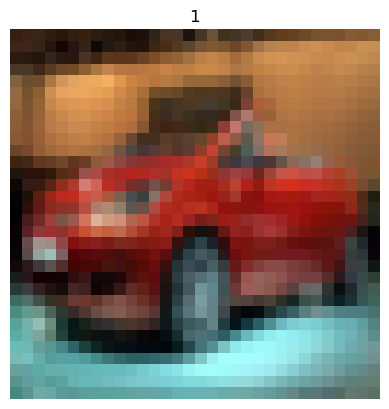

In [8]:
import matplotlib.pyplot as plt

plt.imshow(image.permute(1, 2, 0))
plt.title(label)
plt.axis("off")
plt.show()

## Data Loaders

In [9]:
train_loader = DataLoader(train_data, shuffle=True, batch_size=64)
test_loader = DataLoader(test_data, shuffle=False, batch_size=64)

## Defining Model

In [10]:
class CTen(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(64*4*4 , 128),
            nn.ReLU(),
            nn.Linear(128 , 10)
        )

    def forward(self , x):
        x = self.features(x)
        x = x.view(x.size(0) , -1)
        x = self.classifier(x)
        return x

model = CTen().to(device)


## Loss Function and Optimizer

In [11]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters() , lr=0.001)

## Training

In [12]:
epochs = 20
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for images , labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        output = model(images)
        loss = loss_fn(output , labels)
        loss.backward()
        optimizer.step()
        total_loss +=loss.item()
    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f}")

Epoch 1/20 | Loss: 1251.5029
Epoch 2/20 | Loss: 977.2986
Epoch 3/20 | Loss: 851.0878
Epoch 4/20 | Loss: 766.8757
Epoch 5/20 | Loss: 697.1037
Epoch 6/20 | Loss: 649.0005
Epoch 7/20 | Loss: 606.4372
Epoch 8/20 | Loss: 568.0596
Epoch 9/20 | Loss: 532.3460
Epoch 10/20 | Loss: 502.8967
Epoch 11/20 | Loss: 477.3500
Epoch 12/20 | Loss: 448.4664
Epoch 13/20 | Loss: 424.1320
Epoch 14/20 | Loss: 402.2222
Epoch 15/20 | Loss: 380.9235
Epoch 16/20 | Loss: 356.8547
Epoch 17/20 | Loss: 340.1200
Epoch 18/20 | Loss: 319.9793
Epoch 19/20 | Loss: 299.2977
Epoch 20/20 | Loss: 286.0626


## Training Accuracy

In [13]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images , labels in train_loader:
        output = model(images)
        prediction = output.argmax(dim=1)
        correct += (prediction == labels).sum().item()
        total += labels.size(0)
train_accuracy = 100 * correct / total
print("Train Accuracy:" , train_accuracy , "%")

Train Accuracy: 88.852 %


## Testing Accuracy

In [14]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images , labels in test_loader:
        output = model(images)
        prediction = output.argmax(dim=1)
        correct += (prediction == labels).sum().item()
        total +=labels.size(0)
test_accuracy = 100 * correct/total
print("Test Accuracy:" , test_accuracy , "%")

Test Accuracy: 73.01 %


## Saving Model

In [15]:
torch.save(model.state_dict() , "CIFAR10.pth")

## Testing Real World Image

In [26]:
from PIL import Image
img = Image.open("images/ship.jpg")
transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])
img = transform(img)
img = img.unsqueeze(0)
print(img.shape)

torch.Size([1, 3, 32, 32])


## Predicting

In [27]:
model.eval()
with torch.no_grad():
    output = model(img)
    pred = output.argmax(dim=1)
print(pred)

tensor([8])
